In [2]:
import os
os.chdir(r'C:\Users\PC\MarketPulse360')

In [3]:
# ============================================
# CELLULE 1 — Pricing Analysis
# ============================================
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from dotenv import load_dotenv
import os

load_dotenv()
engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)

df = pd.read_sql("""
    SELECT fo.*, dp.category
    FROM fact_orders fo
    JOIN dim_products dp ON fo.product_id = dp.product_id
""", engine)

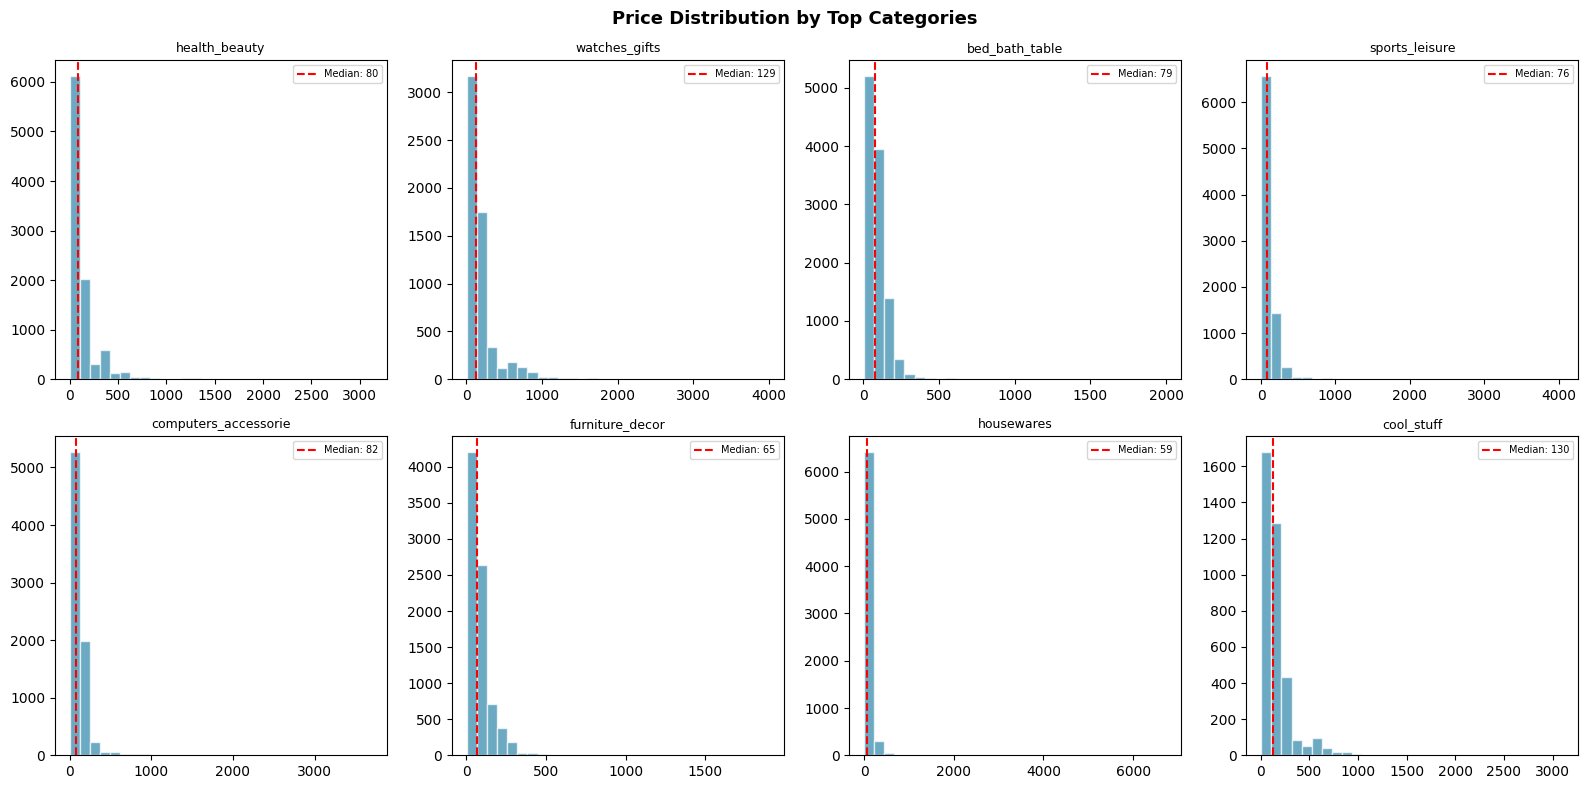

In [4]:
# ============================================
# CELLULE 2 — Distribution des prix par catégorie
# ============================================
top_categories = df.groupby('category')['product_price'].sum().nlargest(8).index

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, cat in enumerate(top_categories):
    data = df[df['category'] == cat]['product_price']
    axes[i].hist(data, bins=30, color='#2E86AB', alpha=0.7, edgecolor='white')
    axes[i].set_title(cat[:20], fontsize=9)
    axes[i].axvline(data.median(), color='red', linestyle='--', label=f'Median: {data.median():.0f}')
    axes[i].legend(fontsize=7)
plt.suptitle('Price Distribution by Top Categories', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/price_distribution.png', dpi=150)
plt.show()

C:\Users\PC\AppData\Local\Temp\ipykernel_3776\97174725.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(category_pricing['category'], rotation=45, ha='right', fontsize=8)


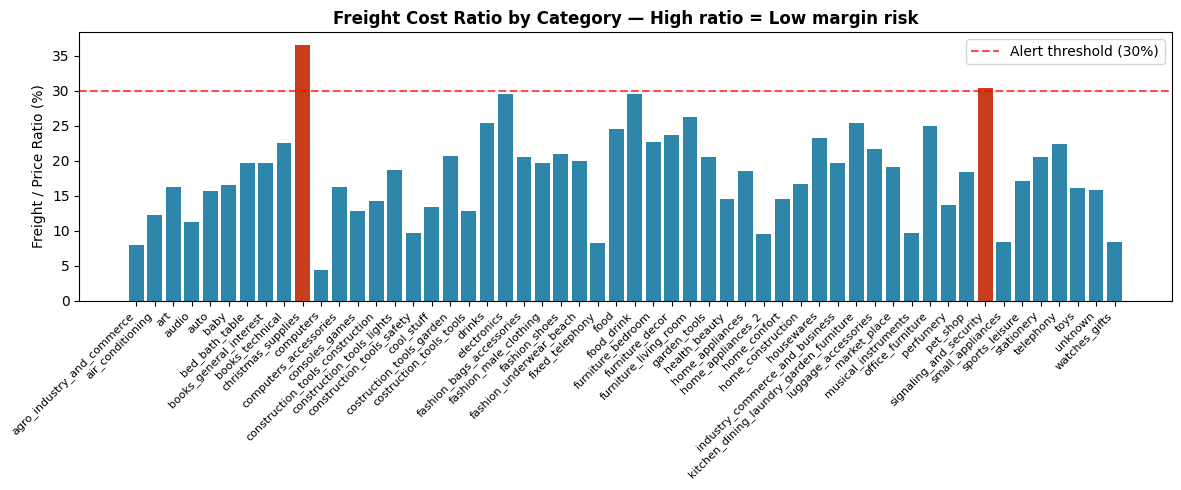

In [5]:
# ============================================
# CELLULE 3 — Freight ratio (proxy coût logistique)
# ============================================
category_pricing = df.groupby('category').agg(
    avg_price=('product_price', 'mean'),
    avg_freight=('freight_value', 'mean'),
    nb_orders=('order_id', 'count'),
    avg_review=('review_score', 'mean')
).reset_index()
category_pricing['freight_ratio'] = category_pricing['avg_freight'] / category_pricing['avg_price'] * 100
category_pricing = category_pricing[category_pricing['nb_orders'] > 100]

fig, ax = plt.subplots(figsize=(12, 5))
colors_bar = ['#C73E1D' if x > 30 else '#2E86AB' for x in category_pricing['freight_ratio']]
bars = ax.bar(category_pricing['category'], category_pricing['freight_ratio'], color=colors_bar)
ax.axhline(y=30, color='red', linestyle='--', alpha=0.7, label='Alert threshold (30%)')
ax.set_xticklabels(category_pricing['category'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Freight / Price Ratio (%)')
ax.set_title('Freight Cost Ratio by Category — High ratio = Low margin risk', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('reports/freight_ratio.png', dpi=150)
plt.show()

Anomalies détectées : 23,765 (21.44%)


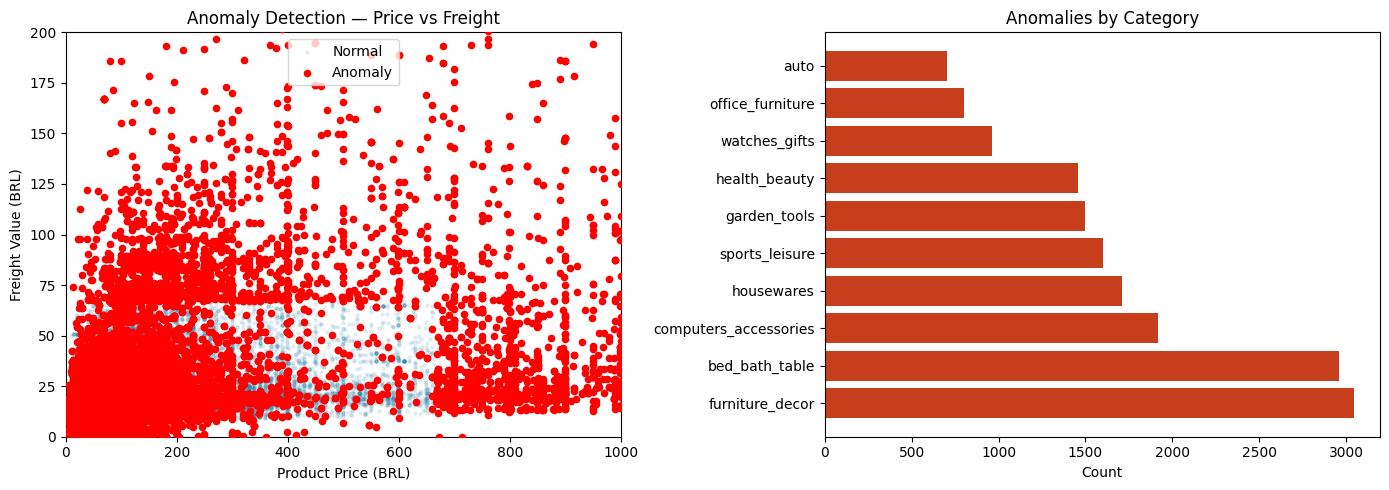

In [6]:
# ============================================
# CELLULE 4 — Anomaly Detection (Z-score)
# ============================================
df['price_zscore']   = np.abs(stats.zscore(df['product_price'].fillna(0)))
df['freight_zscore'] = np.abs(stats.zscore(df['freight_value'].fillna(0)))
df['payment_gap']    = np.abs(df['product_price'] + df['freight_value'] - df['payment_value'].fillna(0))

df['is_anomaly'] = (
    (df['price_zscore']   > 3) |
    (df['freight_zscore'] > 3) |
    (df['payment_gap']    > 50) |
    (df['product_price']  <= 0)
)

anomalies = df[df['is_anomaly']].copy()
print(f"Anomalies détectées : {len(anomalies):,} ({len(anomalies)/len(df)*100:.2f}%)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(df[~df['is_anomaly']]['product_price'],
                df[~df['is_anomaly']]['freight_value'],
                alpha=0.1, color='#2E86AB', s=5, label='Normal')
axes[0].scatter(anomalies['product_price'], anomalies['freight_value'],
                color='red', s=20, label='Anomaly', zorder=5)
axes[0].set_xlabel('Product Price (BRL)')
axes[0].set_ylabel('Freight Value (BRL)')
axes[0].set_title('Anomaly Detection — Price vs Freight')
axes[0].legend()
axes[0].set_xlim(0, 1000)
axes[0].set_ylim(0, 200)

anomaly_by_cat = anomalies.groupby('category').size().sort_values(ascending=False).head(10)
axes[1].barh(anomaly_by_cat.index, anomaly_by_cat.values, color='#C73E1D')
axes[1].set_title('Anomalies by Category')
axes[1].set_xlabel('Count')
plt.tight_layout()
plt.savefig('reports/anomaly_detection.png', dpi=150)
plt.show()

In [7]:
# ============================================
# CELLULE 5 — Export
# ============================================
df.to_csv('data/processed/pricing_analysis.csv', index=False)
anomalies[['order_id', 'product_id', 'category', 'product_price',
           'freight_value', 'payment_gap', 'price_zscore']]\
    .to_csv('data/processed/anomalies.csv', index=False)
print(f"✅ Exports OK — {len(anomalies)} anomalies enregistrées")

✅ Exports OK — 23765 anomalies enregistrées
